<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/model%20to%20predict%20cryptocurrency%20price%20trends%20using%20time-series%20data..ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cryptocurrency Price Trend Prediction using Deep Learning

This notebook demonstrates how to build a time-series forecasting model for Bitcoin prices using a Recurrent Neural Network (RNN).

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU

# Download historical Bitcoin data
df = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01')
display(df.head())

/tmp/ipykernel_11986/3127762647.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


## Data Preprocessing
We will normalize the 'Close' prices and create sliding window sequences for the model to learn from.

In [3]:
# Feature selection
data = df[['Close']].values

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences (e.g., use last 60 days to predict next day)
prediction_days = 60
x_train, y_train = [], []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x-prediction_days:x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f'Training shape: {x_train.shape}')

Training shape: (1401, 60, 1)


## Model Building
We will define a GRU model architecture which is often more efficient than LSTM for time-series tasks.

In [4]:
model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=25, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - loss: 0.0153
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0033
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0033
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0029
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0026
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0026
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0023
Epoch 8/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.0021
Epoch 9/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0020
Epoch 10/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0020
Epoch 11/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0021
Epoch 12/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0019
Epoch 13/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0019
Epoch 14/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0023
Epoch 15/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0018
E

/tmp/ipykernel_11986/1925658881.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_df = yf.download("BTC-USD", start=test_start, end=test_end)
[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


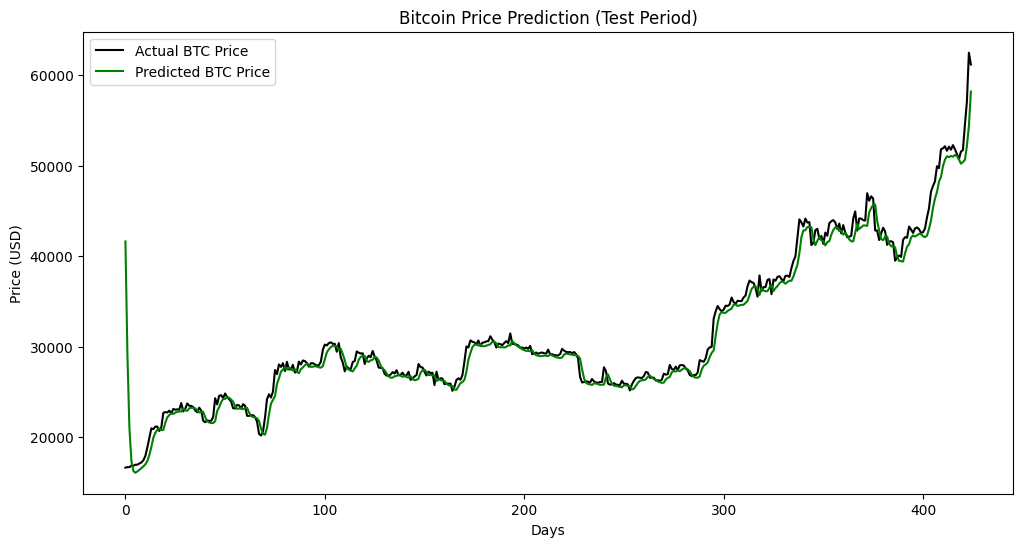

In [5]:
# Prepare test data (using more recent data for evaluation)
test_start = "2023-01-01"
test_end = "2024-03-01"
test_df = yf.download("BTC-USD", start=test_start, end=test_end)
actual_prices = test_df["Close"].values

# Combine datasets to get the required window for the first test prediction
total_dataset = pd.concat((df["Close"], test_df["Close"]), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_df) - prediction_days:].values
model_inputs = model_inputs.reshape(-1, 1)
model_inputs = scaler.transform(model_inputs)

x_test = []

for x in range(prediction_days, len(model_inputs)):
    x_test.append(model_inputs[x-prediction_days:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Make predictions
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

# Visualize the results
plt.figure(figsize=(12,6))
plt.plot(actual_prices, color="black", label="Actual BTC Price")
plt.plot(predicted_prices, color="green", label="Predicted BTC Price")
plt.title("Bitcoin Price Prediction (Test Period)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [6]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error
mse = mean_squared_error(actual_prices, predicted_prices)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate Root Mean Squared Error for a more interpretable scale (USD)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Mean Squared Error (MSE): 3093971.07
Root Mean Squared Error (RMSE): $1758.97
